In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ")


All libraries imported successfully 


In [18]:
col_names = ['unit', 'cycles', 'op_setting1', 'op_setting2', 'op_setting3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

# Load training data
train_df = pd.read_csv(
    'd:/Turbofan_RUL_Project/data/CMaps/train_FD001.txt',
    sep='\s+', header=None, names=col_names
)

print('Shape:', train_df.shape)
print('Columns:', train_df.columns.tolist())
train_df.head()

Shape: (20631, 26)
Columns: ['unit', 'cycles', 'op_setting1', 'op_setting2', 'op_setting3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


,unit,cycles,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [19]:
max_cycles = train_df.groupby('unit')['cycles'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycles']

train_df = train_df.merge(max_cycles, on='unit')
train_df['RUL'] = train_df['max_cycles'] - train_df['cycles']

train_df.drop(columns=['max_cycles'], inplace=True)

print('RUL column added!')
print(train_df[['unit', 'cycles', 'RUL']].head(10))

RUL column added!
   unit  cycles  RUL
0     1       1  191
1     1       2  190
2     1       3  189
3     1       4  188
4     1       5  187
5     1       6  186
6     1       7  185
7     1       8  184
8     1       9  183
9     1      10  182


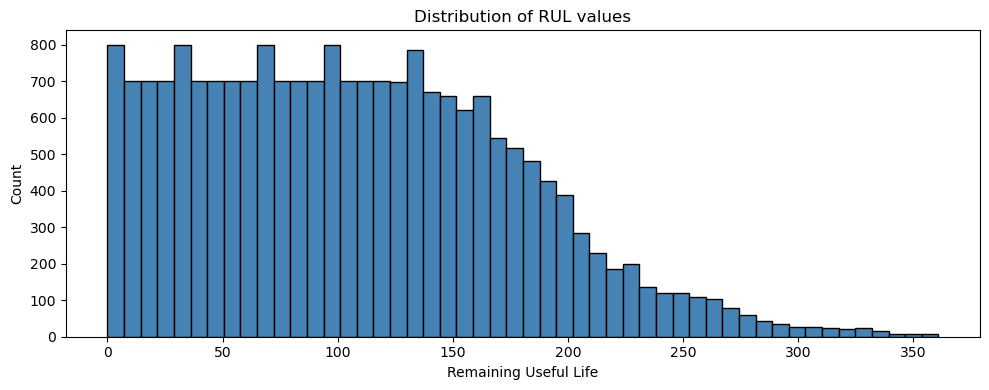

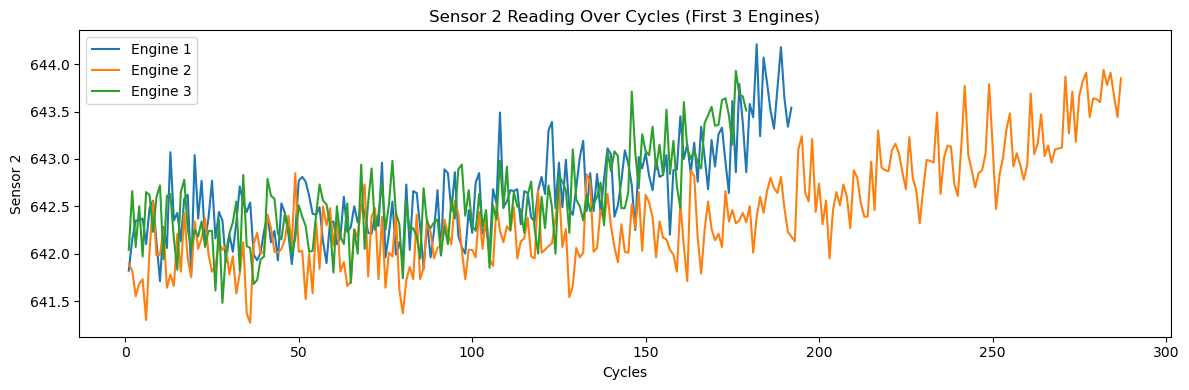

Charts saved


In [20]:
plt.figure(figsize=(10, 4))
plt.hist(train_df['RUL'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of RUL values')
plt.xlabel('Remaining Useful Life')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('d:/Turbofan_RUL_Project/output/rul_distribution.png')
plt.show()

plt.figure(figsize=(12, 4))
for unit in [1, 2, 3]:
    data = train_df[train_df['unit'] == unit]
    plt.plot(data['cycles'], data['sensor_2'], label=f'Engine {unit}')
plt.title('Sensor 2 Reading Over Cycles (First 3 Engines)')
plt.xlabel('Cycles')
plt.ylabel('Sensor 2')
plt.legend()
plt.tight_layout()
plt.savefig('d:/Turbofan_RUL_Project/output/sensor2_trend.png')
plt.show()

print("Charts saved")

In [21]:
drop_cols = ['op_setting3', 'sensor_1', 'sensor_5', 'sensor_6', 
             'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

train_df.drop(columns=drop_cols, inplace=True)


X = train_df.drop(columns=['unit', 'RUL'])
y = train_df['RUL']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print('Features shape:', X_scaled.shape)
print('Target shape:', y.shape)
print('Preprocessing done')

Features shape: (20631, 17)
Target shape: (20631,)
Preprocessing done


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("\nModel trained successfully!")

Train size: (16504, 17)
Test size: (4127, 17)

Model trained successfully!


Model Evaluation Results:
MAE  : 25.43
RMSE : 35.93
R2   : 0.7174


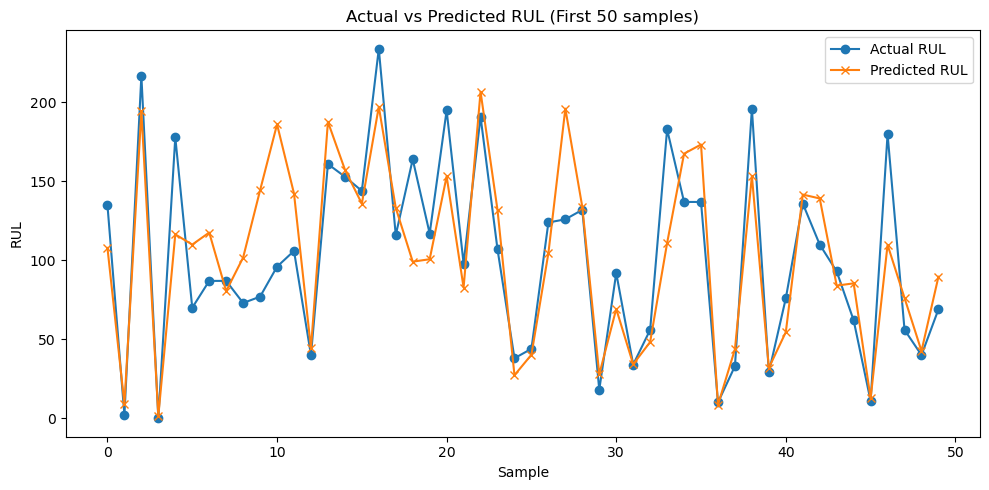

Chart saved! ✅


In [23]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Model Evaluation Results:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Actual RUL', marker='o')
plt.plot(y_pred[:50], label='Predicted RUL', marker='x')
plt.title('Actual vs Predicted RUL (First 50 samples)')
plt.xlabel('Sample')
plt.ylabel('RUL')
plt.legend()
plt.tight_layout()
plt.savefig('d:/Turbofan_RUL_Project/output/actual_vs_predicted.png')
plt.show()
print("Chart saved! ✅")

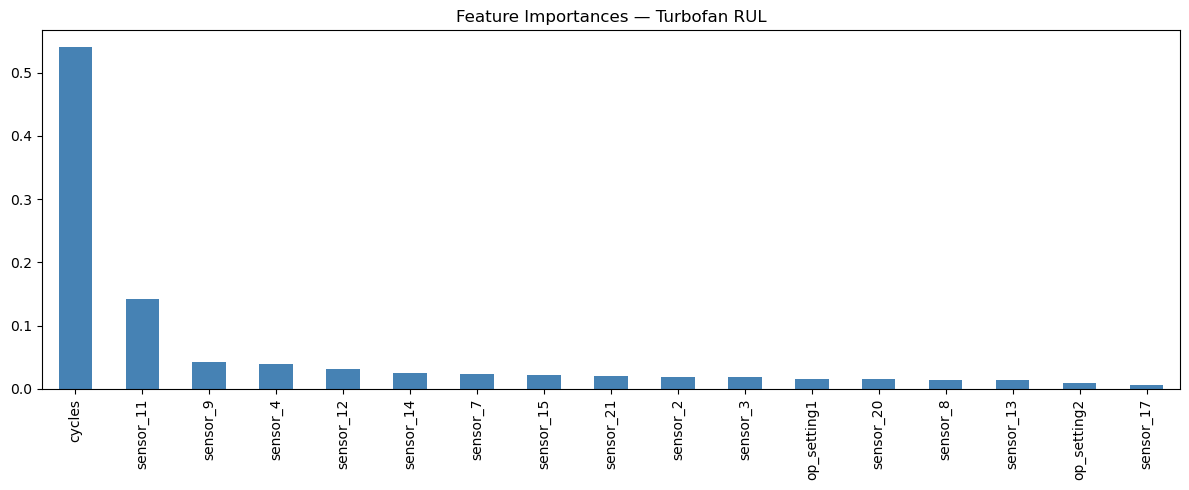

✅ Feature importance chart saved!
✅ Predictions CSV saved!

🎉 PROJECT 6 COMPLETE!


In [24]:
# Feature Importance
feature_names = train_df.drop(columns=['unit', 'RUL']).columns
feat_imp = pd.Series(model.feature_importances_, index=feature_names)

feat_imp.sort_values(ascending=False).plot(
    kind='bar', figsize=(12, 5), color='steelblue',
    title='Feature Importances — Turbofan RUL')
plt.tight_layout()
plt.savefig('d:/Turbofan_RUL_Project/output/feature_importance.png')
plt.show()

# Save predictions
results = pd.DataFrame({
    'Actual_RUL': y_test.values,
    'Predicted_RUL': y_pred.round(2)
})
results.to_csv('d:/Turbofan_RUL_Project/output/predictions.csv', index=False)

print("✅ Feature importance chart saved!")
print("✅ Predictions CSV saved!")
print("\n🎉 PROJECT 6 COMPLETE!")